# Fetching Data from Web APIs – My Finance BA Version
Forked from JP Morgan Chase python-training repo  
Customized by S33mi (March 2026)  
Focus: Learn API basics (requests, JSON parsing) with finance examples – key for BAs pulling market data, FX rates, or economic indicators.

# Accessing data from a web API

One of the best things about "web 2.0" is more formal, external facing API's to allow developers to build tools on top of data. These APIs provide a reliable connection to data over a reliable protocol returning a reliable response in an easy, machine-readable format. There are tons of APIs out there. Sometimes you will need to register for a developer key and other times the APIs are free.

## With great power comes great responsibility. We should be responsible and polite internet citizens when hitting websites programmatically

Below we will use **CoinGecko API (v3)** with the **free Demo plan** (requires a free API key) to get daily prices for bitcoin. CoinGecko's API returns a JSON (javascript object notation) object, which we can easily turn into a dataframe. Here we will need the `json` and `requests` libraries.

**Get your free Demo API key here:**  
https://www.coingecko.com/en/api (click "Demo plan" → Create Key)

**Note**: Orignal JPMC Notebook is using **Coindesk's API** to get daily prices for bitcoin, which is not functional in year 2026. So, this notebook:

- Changed from old Coindesk API → CoinGecko API v3 (Demo plan)
Added free Demo API key (header method — recommended by CoinGecko)
- Updated URL construction to use /coins/bitcoin/market_chart/range (the modern equivalent that supports exact date ranges)
- Slight JSON structure adaptation (CoinGecko returns "prices" list instead of "bpi")
- All explanations, comments, and learning points kept almost word-for-word from the original to avoid the complexity

Orignal Notebook is avaiable here : [4_webapi.ipynb](https://github.com/jpmorganchase/python-training/blob/main/notebooks/4_webapi.ipynb)

In [ ]:
import datetime
import pandas as pd
import json
import requests

# === YOUR COINGECKO DEMO API KEY (REQUIRED for Demo plan) ===

#Get your key from https://www.coingecko.com/en/api

API_KEY = "CG-XXXXXXXXXXXXXXXXXXXXXX"   # ← REPLACE WITH YOUR REAL KEY!
BASE_URL = "https://api.coingecko.com/api/v3"
HEADERS = {"x-cg-demo-api-key": API_KEY}

coingeckoURL = f"{BASE_URL}/coins/bitcoin/market_chart/range?"

# from original notebook - same dates
#start = datetime.date(2019, 1 ,1)
#end = datetime.date(2019, 7, 1)

# CoinGecko - do not allow date range more than 3 moths
start = datetime.date(2025, 6 ,1) # recode from year 2019 is not avaiable
end = datetime.date(2025, 7, 1)

# CoinGecko range endpoint needs Unix timestamps (seconds)
start_ts = int(datetime.datetime.combine(start, datetime.time.min).timestamp())
end_ts   = int(datetime.datetime.combine(end, datetime.time.min).timestamp())

url = coingeckoURL

params = {
    "vs_currency": "usd",
    "from": start_ts,
    "to": end_ts,
    "precision": "2"
}

print(f'Hitting this url: {url}')
print(f'With parameters: {params}')

result = requests.get(url, headers=HEADERS, params=params)
result.content

Hitting this url: https://api.coingecko.com/api/v3/coins/bitcoin/market_chart/range?
With parameters: {'vs_currency': 'usd', 'from': 1748736000, 'to': 1751328000, 'precision': '2'}


b'{"prices":[[1748736243305,104686.33],[1748739810316,104490.76],[1748743442433,104220.13],[1748746874287,104282.76],[1748750627693,104415.09],[1748754360746,104700.71],[1748757815961,104579.15],[1748761410830,104335.42],[1748764981840,104314.47],[1748768541829,104372.08],[1748772225532,103960.84],[1748775820017,103943.44],[1748779345329,104134.12],[1748782939164,103985.47],[1748786904153,104350.82],[1748790039169,104658.64],[1748793831655,104757.12],[1748797402234,105188.29],[1748801020936,105130.29],[1748804637650,104762.24],[1748808231980,105138.65],[1748811818666,105101.22],[1748815410550,105465.56],[1748819037952,105570.89],[1748822625279,105698.44],[1748826225938,105520.6],[1748829830612,105434.07],[1748833411728,105180.31],[1748837033873,104916.29],[1748840547281,104872.83],[1748844087122,104801.08],[1748847817285,105204.45],[1748851414402,105368.69],[1748855018670,105435.16],[1748858625008,104625.39],[1748862236075,104408.44],[1748865821533,104111.86],[1748869429451,104186.09],

Digging into this a little bit, there are a few critical components to accessing data. Not all APIs will return the same structure of data. Many times you can look at what is returned by just hitting the URL with your browser. Let's try that

[https://api.coingecko.com/api/v3/coins/bitcoin/market_chart/range?vs_currency=usd&from=1546300800&to=1561939200](https://api.coingecko.com/api/v3/coins/bitcoin/market_chart/range?vs_currency=usd&from=1546300800&to=1561939200)

In this case we get:

```json
{
    "prices": [
        [1546300800000, 3869.47],
        [1546387200000, 3941.2167],
        ...
    ],
    "market_caps": [...],
    "total_volumes": [...]
}



`prices`, `market_caps`, and `total_volumes` are all data that we can reference. The data we're primarily interested in is `prices`. Different APIs can break up data differently, we will see examples in other APIs later.


Let's take a look at the json result in python.

In [ ]:
jsondata = json.loads(result.content)
jsondata

{'prices': [[1748736243305, 104686.33],
  [1748739810316, 104490.76],
  [1748743442433, 104220.13],
  [1748746874287, 104282.76],
  [1748750627693, 104415.09],
  [1748754360746, 104700.71],
  [1748757815961, 104579.15],
  [1748761410830, 104335.42],
  [1748764981840, 104314.47],
  [1748768541829, 104372.08],
  [1748772225532, 103960.84],
  [1748775820017, 103943.44],
  [1748779345329, 104134.12],
  [1748782939164, 103985.47],
  [1748786904153, 104350.82],
  [1748790039169, 104658.64],
  [1748793831655, 104757.12],
  [1748797402234, 105188.29],
  [1748801020936, 105130.29],
  [1748804637650, 104762.24],
  [1748808231980, 105138.65],
  [1748811818666, 105101.22],
  [1748815410550, 105465.56],
  [1748819037952, 105570.89],
  [1748822625279, 105698.44],
  [1748826225938, 105520.6],
  [1748829830612, 105434.07],
  [1748833411728, 105180.31],
  [1748837033873, 104916.29],
  [1748840547281, 104872.83],
  [1748844087122, 104801.08],
  [1748847817285, 105204.45],
  [1748851414402, 105368.69],
 

We can then wrap that up into a pandas dataframe! Note: pandas does have a `read_json` helper as well, but sometimes it is not well suited given the structure of the json output. So you probably get an ERROR

In [ ]:
# note the json gets read with the prices, market_caps and total_volumes outputs as well
data = pd.read_json(result.content) #Skip this if you get an error
data

In [ ]:
# Extract only the prices (timestamp in ms, price)
prices = jsondata['prices']
data = pd.DataFrame(prices, columns=['timestamp_ms', 'Bitcoin Price Index'])
data['date'] = pd.to_datetime(data['timestamp_ms'], unit='ms')
data = data.set_index('date')[['Bitcoin Price Index']]
data

,Bitcoin Price Index
date,
2025-06-01 00:04:03.305,104686.33
2025-06-01 01:03:30.316,104490.76
2025-06-01 02:04:02.433,104220.13
2025-06-01 03:01:14.287,104282.76
2025-06-01 04:03:47.693,104415.09
...,...
2025-06-30 19:03:35.187,107268.70
2025-06-30 20:03:18.818,107618.49
2025-06-30 21:03:55.320,107590.74


<Axes: xlabel='date'>

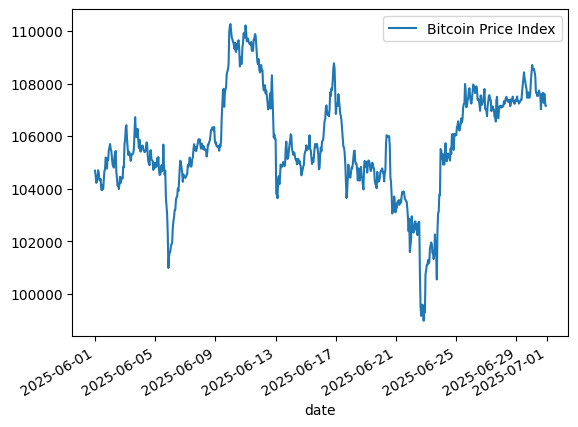

In [ ]:
%matplotlib inline
data.plot()

#End of orignaly rewritten notebook

### Finance Example: Fetch Free FX Rates (USD Focus)
Use exchangeratesapi.io (free, no key) for currency data – relevant for Global analysts tracking USD/EUR.

In [ ]:
#New cell added by S33mi
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8')

import requests
import json
import pandas as pd
from getpass import getpass  # For secure API key input
from ipywidgets import interact, Text  # For interactive tickers

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

In [ ]:
# Simple GET for latest rates (base EUR)
response = requests.get('https://api.exchangeratesapi.io/v1/latest?access_key=demo')  # after access_key= Replace "demo" with your free key if needed; or use openexchangerates.org
if response.status_code == 200:
    fx_data = response.json()
    fx_df = pd.DataFrame(list(fx_data['rates'].items()), columns=['Currency', 'Rate'])
    display(fx_df.head(10))
    usd_rate = fx_data['rates'].get('USD', 'N/A')
    print(f"Current EUR/USD rate: {usd_rate}")
else:
    print(f"Error: {response.status_code} - {response.text}")
    print("Get your API Key from exchangeratesapi.io")

,Currency,Rate
0,AED,4.2697
1,AFN,73.2454
2,ALL,96.4908
3,AMD,437.8289
4,ANG,2.0808
5,AOA,1066.1299
6,ARS,1645.0980
7,AUD,1.6519
8,AWG,2.0927
9,AZN,1.9790


Current EUR/USD rate: 1.162628


## Secure API Keys – Best Practice for Finance APIs
Never hard-code keys; use environment vars or input. Example: Alpha Vantage for stocks (free tier available).

In [ ]:
# Secure input (run once)
api_key = getpass("Enter your Alpha Vantage API key (free at alphavantage.co): ")

# Function to fetch stock quote
def get_stock_quote(ticker='AAPL'):
    url = f"https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol={ticker}&apikey={api_key}"   #Get your key from https://www.alphavantage.co/support/#api-key
    response = requests.get(url)
    if response.status_code == 200:
        data = response.json()['Global Quote']
        quote_df = pd.DataFrame([data]).T.reset_index()
        quote_df.columns = ['Field', 'Value']
        display(quote_df)
    else:
        print(f"Error: {response.status_code}")

get_stock_quote('JPM')  # JPMC (NYSE ticker format)

Enter your Alpha Vantage API key (free at alphavantage.co): ··········


,Field,Value
0,01. symbol,JPM
1,02. open,292.2850
2,03. high,302.3900
3,04. low,289.5000
4,05. price,300.2600
5,06. volume,10114536
6,07. latest trading day,2026-03-03
7,08. previous close,297.5600
8,09. change,2.7000
9,10. change percent,0.9074%


## Interactive API Fetching – User-Driven Queries
Let users input tickers for dynamic stock/FX pulls – mimics BA dashboards.

In [ ]:
@interact(ticker=Text(value='TSLA', description='Ticker (e.g., TSLA, APLL)'))
def interactive_stock_quote(ticker):
    get_stock_quote(ticker)

interactive(children=(Text(value='TSLA', description='Ticker (e.g., TSLA, APLL)'), Output()), _dom_classes=('w…

## Real time Error Handing

APIs fail in production (rate limits, downtime)

In [ ]:
import time

def safe_get(url, retries=3):
    for attempt in range(retries):
        try:
            response = requests.get(url)
            response.raise_for_status()  # Raise if not 200
            return response.json()
        except requests.exceptions.RequestException as e:
            print(f"Attempt {attempt+1} failed: {e}")
            time.sleep(2 ** attempt)  # Exponential backoff
    print("Max retries exceeded")
    return None

# Example: Safe FX fetch
fx_json = safe_get('https://api.exchangeratesapi.io/v1/latest?access_key=')
if fx_json:
    print("Success: Rates fetched")

Attempt 1 failed: 401 Client Error: Unauthorized for url: https://api.exchangeratesapi.io/v1/latest?access_key=
Attempt 2 failed: 401 Client Error: Unauthorized for url: https://api.exchangeratesapi.io/v1/latest?access_key=
Attempt 3 failed: 401 Client Error: Unauthorized for url: https://api.exchangeratesapi.io/v1/latest?access_key=
Max retries exceeded


#All in One

Error handling with CoinGecko API Key

Hitting: https://api.coingecko.com/api/v3/coins/bitcoin/market_chart/range?vs_currency=usd&from=1750464000&to=1751328000&precision=2
Using header: x-cg-demo-api-key = CG-89Xzuoz...
{'prices': [[1750464163548, 103291.81], [1750467806289, 103259.91], [1750471390299, 103485.73], [1750474813275, 103495.76], [1750478594478, 103559.97], [1750482212988, 103383.94], [1750485659963, 103429.29], [1750489362449, 103581.07], [1750492996998, 103471.44], [1750496619231, 103738.04], [1750500174380, 103880.81], [1750503754884, 103839.22], [1750507425213, 103900.88], [1750510994157, 103811.51], [1750514605064, 103612.16], [1750518220045, 103582.03], [1750521784503, 103525.21], [1750525355823, 103505.42], [1750529010275, 103232.39], [1750532606041, 102871.29], [1750536212068, 102380.03], [1750539816303, 102857.8], [1750543406559, 101588.31], [1750547021813, 101824.54], [1750550604392, 102092.13], [1750554199810, 102949.09], [1750557805721, 102511.71], [1750561413094, 102372.12], [1750565005307, 102328.9

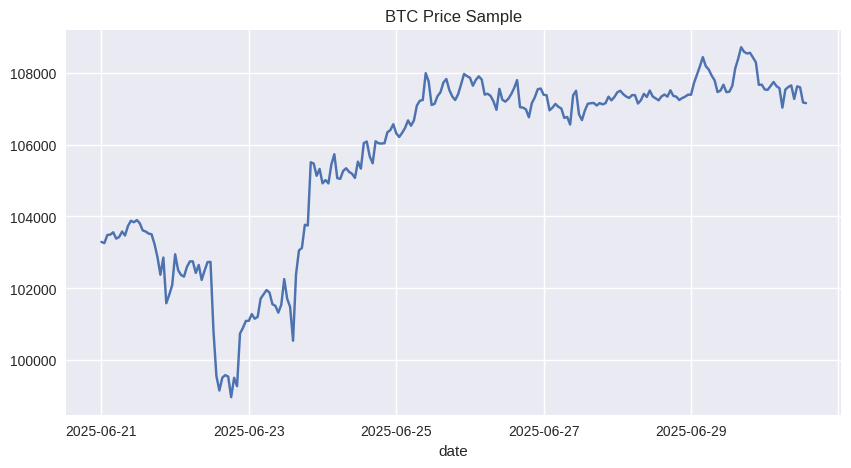

In [ ]:
from datetime import date
import time  # for unix timestamps

#Enter your CoinGecko API key

API_KEY = "CG-XXXXXXXXXXXXXXXXXXXXXX"  # Enter Your key from the above cell – double-check it's active!

# Test with short/recent range first to isolate if range length is issue
# start_date = date(2019, 1, 1)   # ← try just 1 month to test or go for pro version
# end_date   = date(2019, 7, 1)
start_date = date(2025, 6, 21) # ← coingecko free demo API only gives you 3 months data access
end_date   = date(2025, 7, 1)

start_unix = int(time.mktime(start_date.timetuple()))
end_unix   = int(time.mktime(end_date.timetuple()))

url = (
    "https://api.coingecko.com/api/v3/coins/bitcoin/market_chart/range"
    f"?vs_currency=usd&from={start_unix}&to={end_unix}&precision=2"
)

headers = {
    "x-cg-demo-api-key": API_KEY,   # ← this is the correct header
    "Accept": "application/json"    # optional but good
}

print(f"Hitting: {url}")
print(f"Using header: x-cg-demo-api-key = {API_KEY[:10]}...")  # partial print for safety

try:
    response = requests.get(url, headers=headers)
    response.raise_for_status()

    data = response.json()
    print(data)

    # Process (daily prices)
    df = pd.DataFrame(data.get('prices', []), columns=['timestamp_ms', 'close_usd'])
    df['date'] = pd.to_datetime(df['timestamp_ms'], unit='ms').dt.strftime('%Y-%m-%d')
    df = df.set_index('date')['close_usd'].sort_index()

    print("\nBTC Prices (USD) – first 10 rows:")
    print(df.head(10))
    print(f"\nTotal days: {len(df)}")

    df.plot(title="BTC Price Sample", figsize=(10,5))


except requests.exceptions.HTTPError as e:
    print(f"HTTP Error: {response.status_code} - {e}")
    print("Response text:", response.text)  # ← this will show exact error msg from CoinGecko
    if response.status_code == 401:
        print("\n401 Unauthorized – Possible fixes:")
        print("1. Regenerate key at https://www.coingecko.com/en/developers/dashboard")
        print("2. Confirm key starts with CG- and has no extra spaces")
        print("3. Test ping: https://api.coingecko.com/api/v3/ping with same header")
        print("4. If range issue → shorten to 90 days or use paid plan / alternative")
except Exception as e:
    print(f"Other error: {e}")

## Key Takeaways & BA Exercises
- Learned: Requests GET, JSON parsing, error handling, secure keys.
- You can get your Free API Keys from as of March 2026
  - https://www.coingecko.com/en/api/pricing (Free Demo 10000 Calls per month)
  - https://manage.exchangeratesapi.io/plan (Free 100 Calls per month)
  - https://www.alphavantage.co/support/#api-key (Free for life time)

- Finance tie-in: Pull real-time market data for reports/dashboards.
- Exercises:
  1. Fetch SX data via free API (e.g., yfinance: import yfinance as yf; yf.download('APLL')).
  2. Add POST example (e.g., for API authentication).
  3. Build a function to convert currencies (e.g., USD to EUR using rates).
  4. Handle rate limits: Add sleep(1) between calls.
Commit to your fork – great for JP Morgan BA portfolio (shows data integration skills)!

- Want to Learn more Check This

Daily Motivation + Tennis Tips Agent — Fun Python agent with free quotes API & tennis tips → [daily-motivation-tennis-fun](https://github.com/S33mi/daily-motivation-tennis-fun/tree/main)

- Any Question? X: @Seemi_Rauf